# Week 3 Descriptive analysis and visualisation using R

> by Lei Ding, Updated Mar. 2025

In [1]:
# 准备
#install.packages('modeest')
#install.packages('RColorBrewer')
#install.packages('ggplot2')
#install.packages('reshape2')
#install.packages('visdat')
#install.packages('dplyr')
#install.packages('corrplot')
#update.packages(ask=FALSE)

## 1. 描述统计

In [2]:
# 1. 中心趋势度量
df <- iris
head(df)
mean(df$Sepal.Length)
median(df$Sepal.Width)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


[1] 5.843333

[1] 3

In [3]:
# 2. 使用直方图方法估计众数
library(modeest)
mfv(df$Petal.Length)

[1] 1.4 1.5

In [4]:
# 3. 变异性度量
min(df$Sepal.Length)
max(df$Sepal.Length)
range(df$Sepal.Length)
quantile(df$Sepal.Length)  # 四分位数
IQR(df$Sepal.Length)  # 四分位距，即Q3-Q1

[1] 4.3

[1] 7.9

[1] 4.3 7.9

0%  25%  50%  75% 100% 
 4.3  5.1  5.8  6.4  7.9

[1] 1.3

In [5]:
# 4. 其他统计描述方法
summary(df)
str(df)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


In [6]:
# 5. sapply函数：将函数作用到向量或列表上
sapply(df[,-5], median)
sapply(df[,-5], quantile)

Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
        5.80         3.00         4.35         1.30

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0%,4.3,2.0,1.00,0.1
25%,5.1,2.8,1.60,0.3
50%,5.8,3.0,4.35,1.3
75%,6.4,3.3,5.10,1.8
100%,7.9,4.4,6.90,2.5


## 2. 数据可视化

### 2.1 基本R绘图

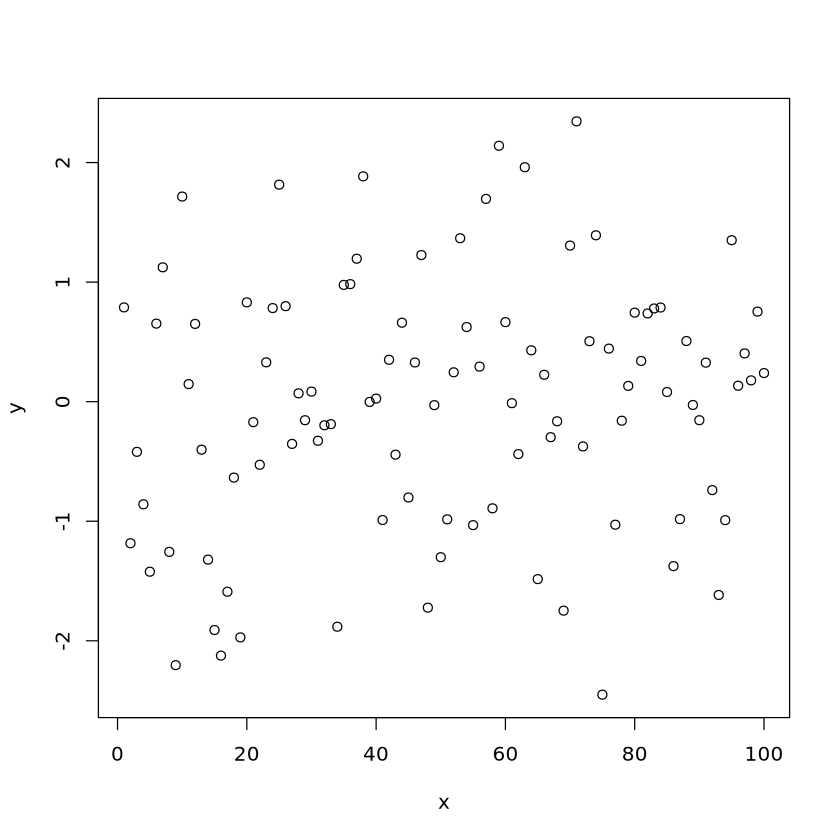

In [7]:
# 6. 散点图
x <- 1:100
y <- rnorm(100)
plot(x, y)

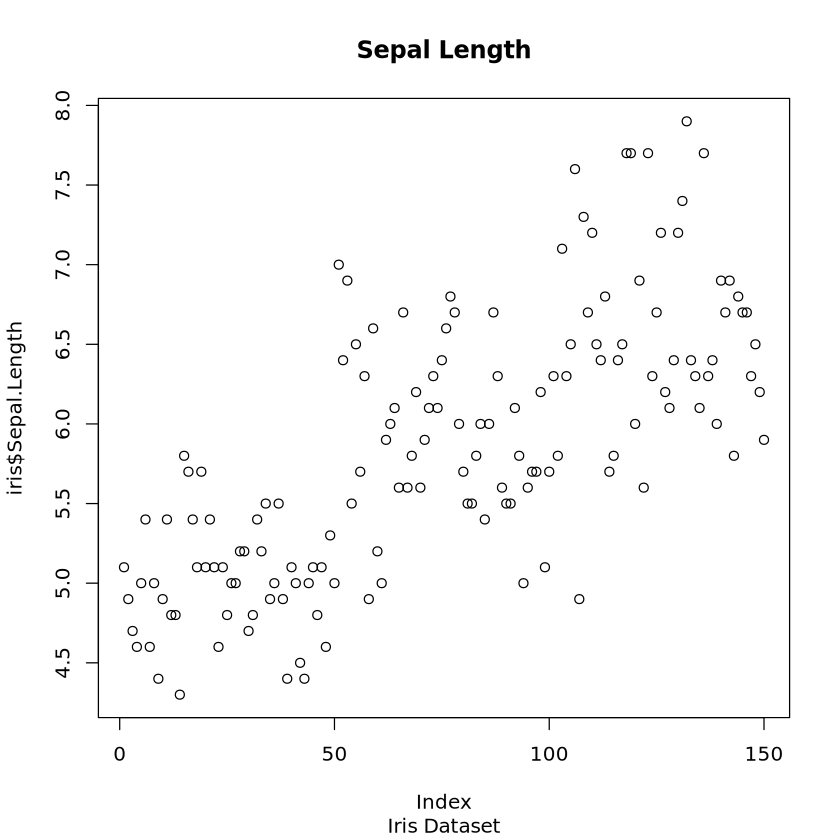

In [8]:
# 7. plot函数的一些参数
plot(iris$Sepal.Length, main='Sepal Length', sub='Iris Dataset')
# xlim, ylim, xlab, ylab

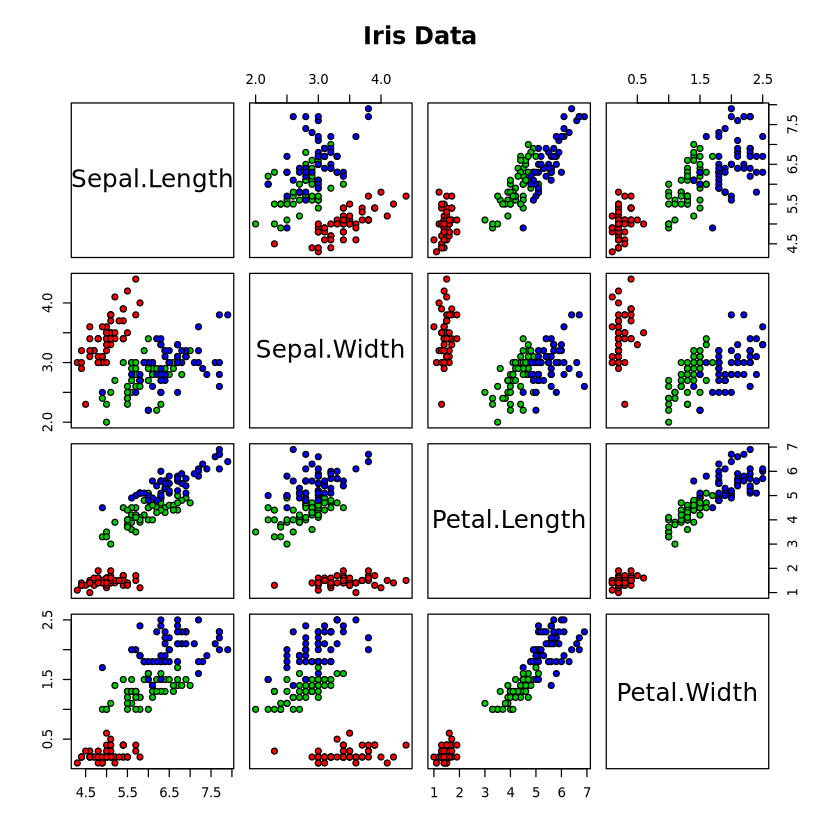

In [9]:
# 8. 散点图矩阵
pairs(iris[-5], main='Iris Data', pch=21, bg=c('red', 'green3', 'blue')[unclass(iris$Species)])

# irir[-5], 排除类别列
# pch: plotting character, see `?points`
# unclass(): 得到因子iris$Species的整数值，并作为颜色向量的索引
# bg: 点类型为21:25时的背景色，see `?points`, `length(colors())` 657种颜色

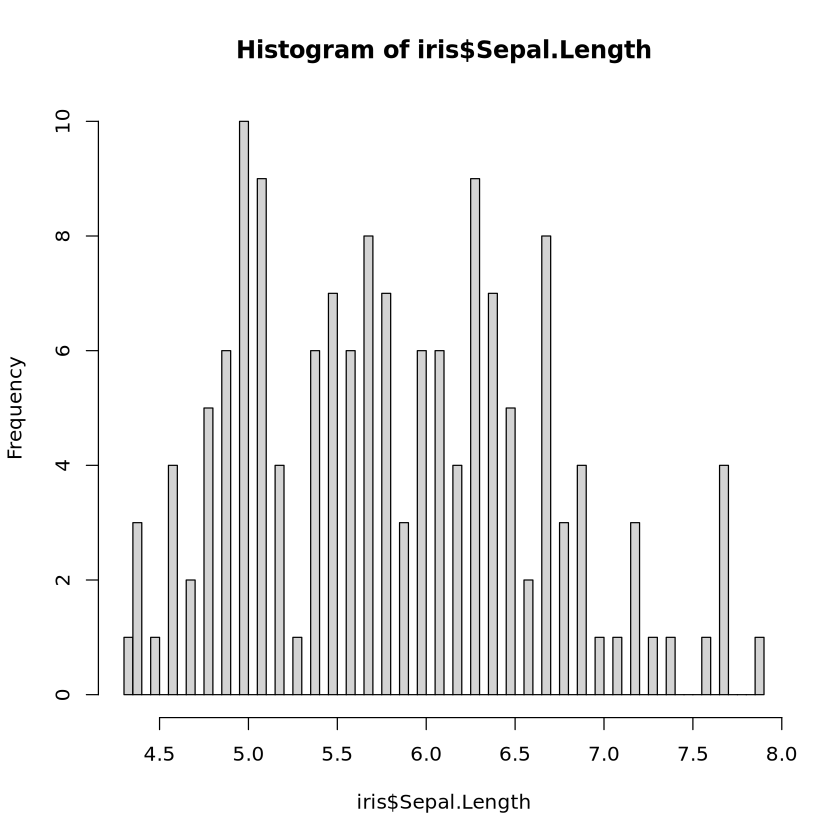

In [10]:
# 9. 直方图
hist(iris$Sepal.Length, breaks=100)

# breaks: 竖条的数量

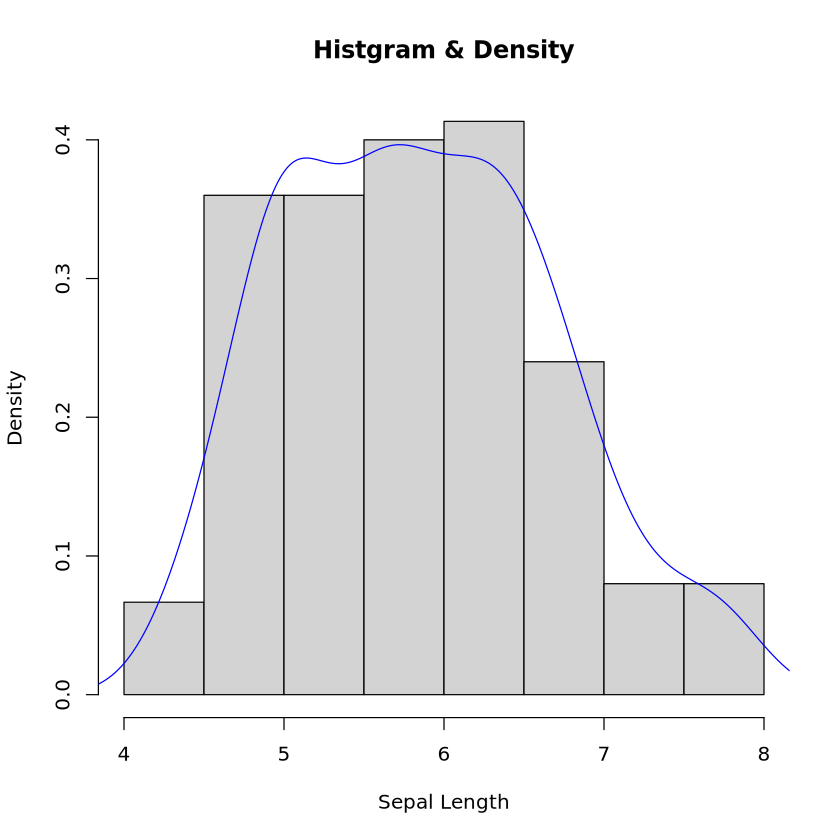

In [11]:
# 10. 直方图与密度曲线
d <- density(iris$Sepal.Length)
hist(iris$Sepal.Length, prob=TRUE, xlab='Sepal Length', main='Histgram & Density')
# prob: 直方图纵轴使用密度（T）表示，否则使用数量（F）表示

lines(d, col='blue')

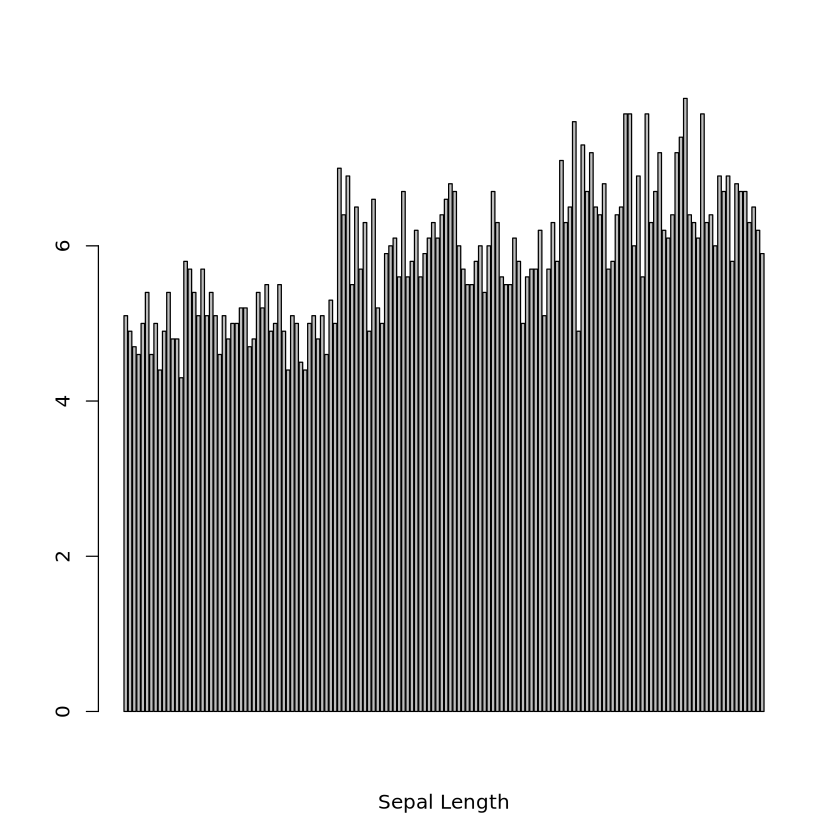

In [12]:
# 11. 条形图
barplot(iris$Sepal.Length, xlab='Sepal Length')

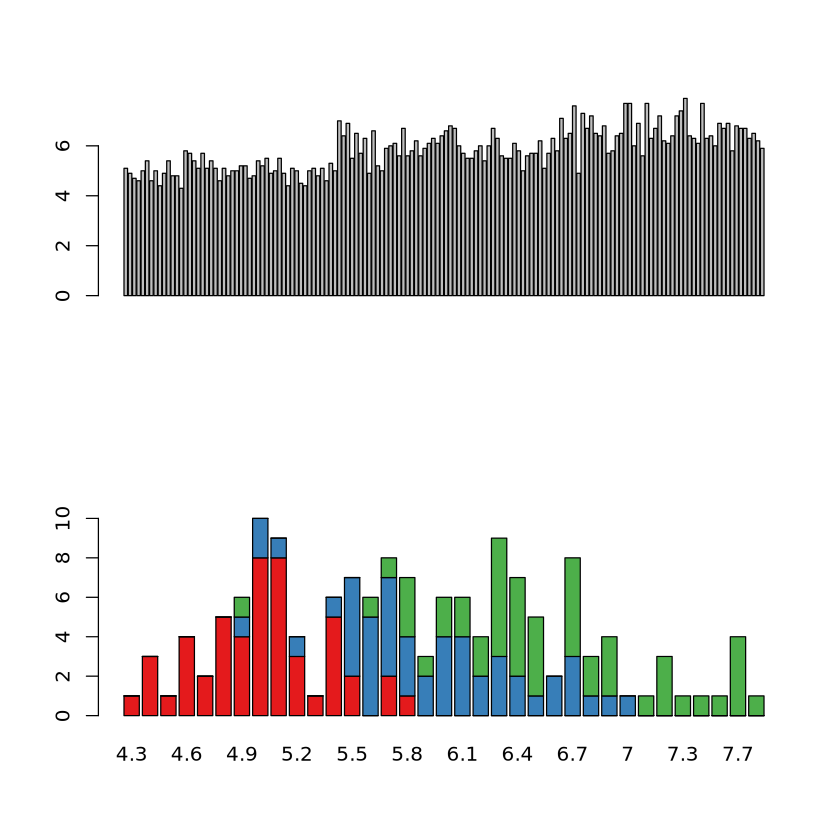

In [13]:
# 12. 多个条形图
par(mfrow=c(2, 1))
# 指定图形参数，mfrow/mfcol：设置布局

barplot(iris$Sepal.Length)

library(RColorBrewer)  # 调色板包, see `?RColorBrewer`
barplot(table(iris$Species, iris$Sepal.Length), col=brewer.pal(3, 'Set1'))
# 绘制频数表，生成分段条形图（堆砌）
# brewer.pal: 调色板，see `brewer.pal.info`，共35种调色板

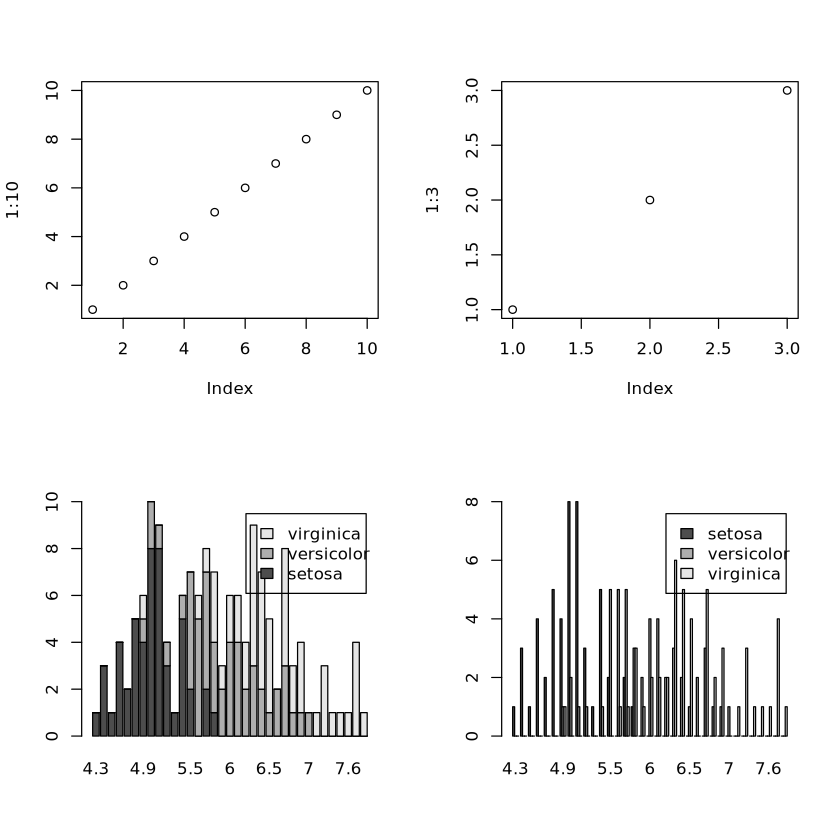

In [14]:
# 13. 一个par例子
par(mfrow=c(2, 2))
plot(1:10)
plot(1:3)
barplot(table(iris$Species, iris$Sepal.Length), legend=TRUE)
barplot(table(iris$Species, iris$Sepal.Length), beside=TRUE, legend=TRUE)

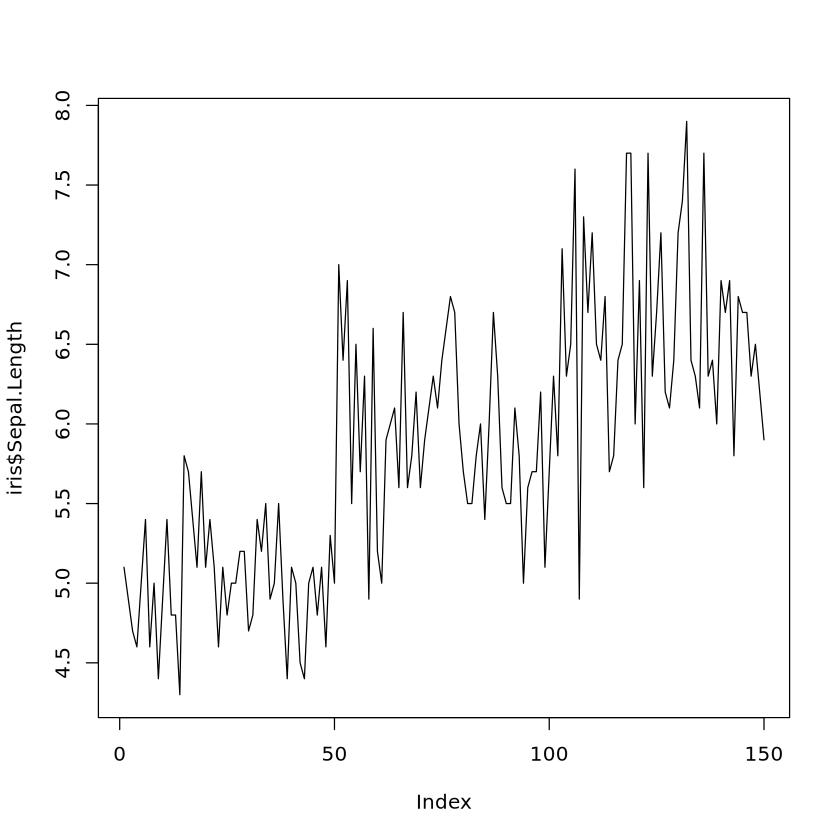

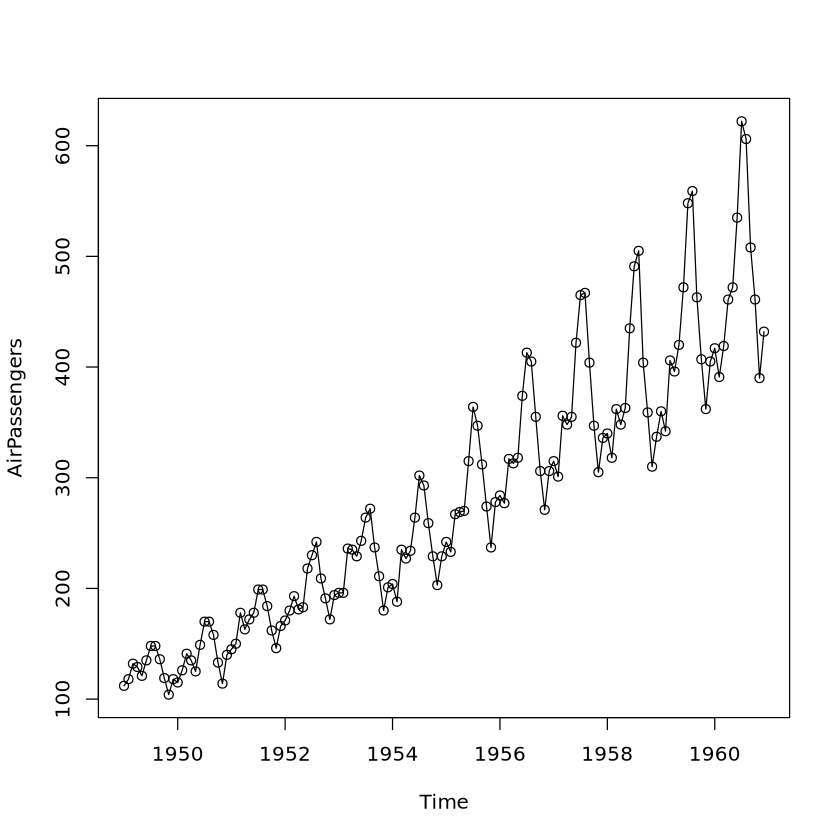

In [15]:
# 14. 线图
plot(iris$Sepal.Length, type='l')
plot(AirPassengers, type='o')  # 一个时间序列数据集

# type: p散点图，l线图，b/c/o同时绘制点和线，see `?plot`

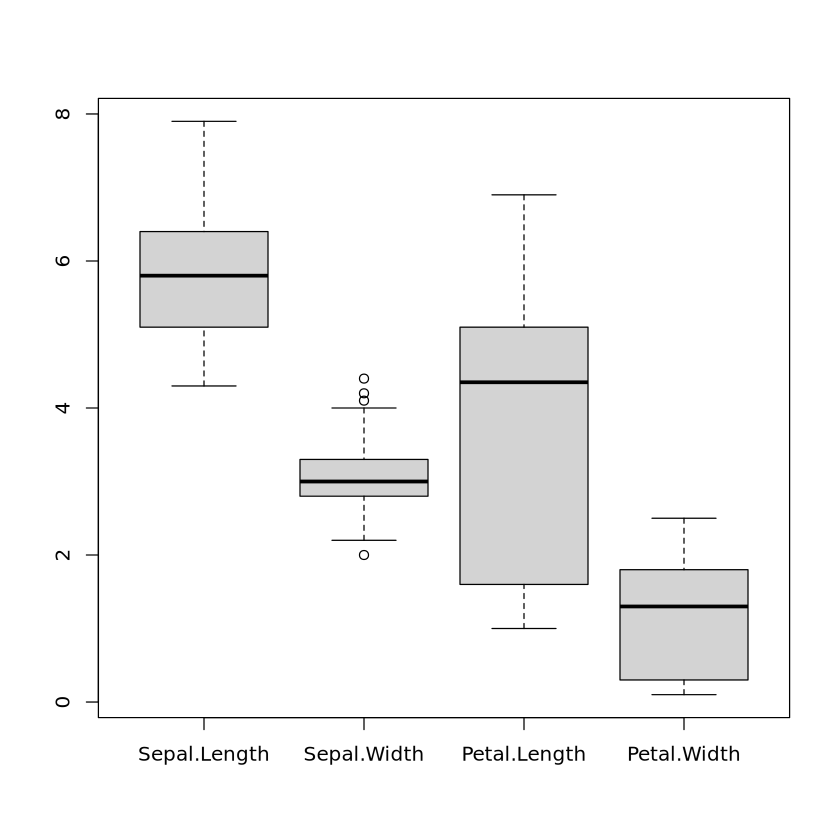

In [16]:
# 15. 盒形图
boxplot(iris[-5])

### 2.2 ggplot绘图

In [17]:
# 加载库
library(ggplot2)

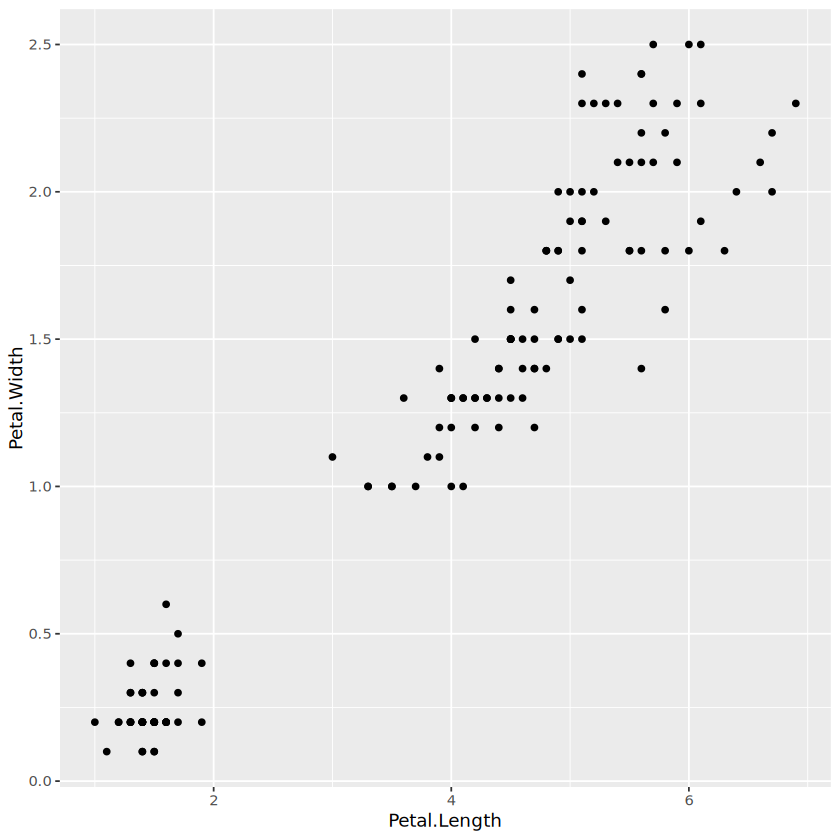

In [18]:
# 16. ggplot > 散点图
g <- ggplot(data=iris, aes(x=Petal.Length, y=Petal.Width))
g + geom_point()

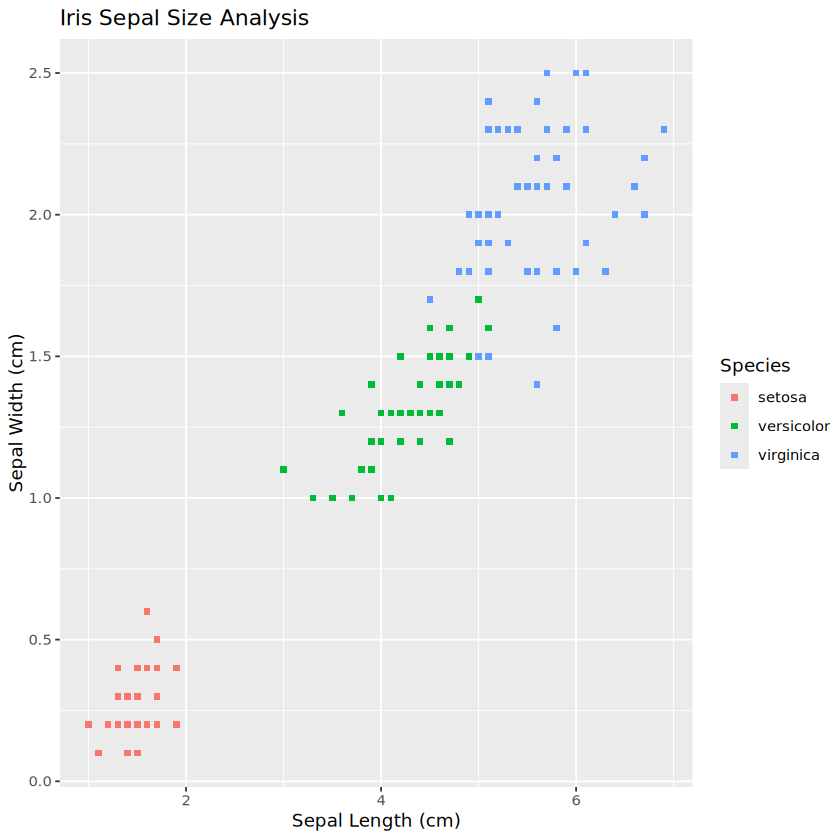

In [19]:
# 17. 更多的图层
g <- ggplot(data=iris, aes(x=Petal.Length, y=Petal.Width))
g + geom_point(aes(col=Species), shape=15, size=1.5) +
    ggtitle('Iris Sepal Size Analysis') +
    labs(x='Sepal Length (cm)', y='Sepal Width (cm)')

# aes: 美学映射，包括x, y, shape, size, color, fill, linetype, alpha, group等，see `?aes`
# shape: 形状，0~25, 或circle
# size: 散点大小
# labs: 坐标轴名称

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


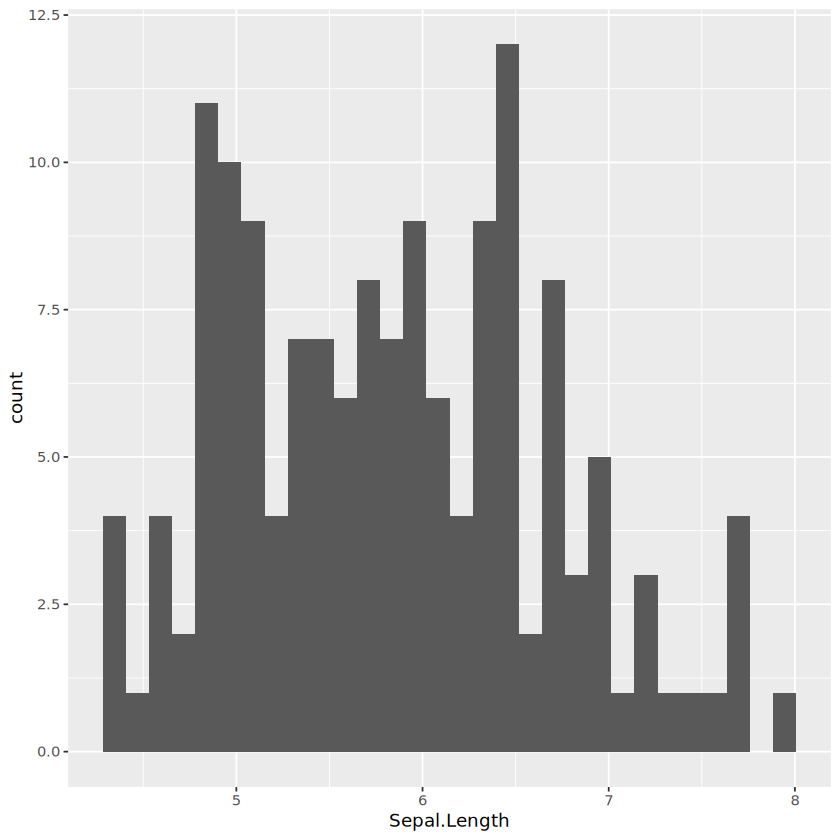

In [20]:
# 18. ggplot > 直方图
ggplot(iris, aes(x=Sepal.Length)) + geom_histogram()

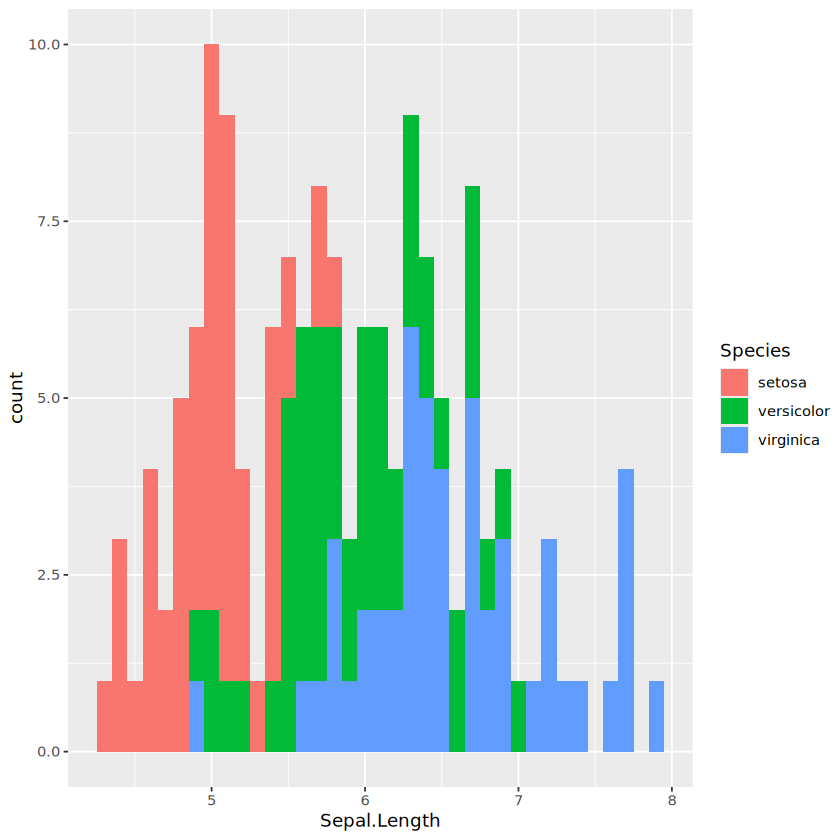

In [21]:
# 更常用的直方图设置
ggplot(iris, aes(x=Sepal.Length, fill=Species)) + geom_histogram(binwidth=0.1)

# fill: 填充颜色，col边框颜色

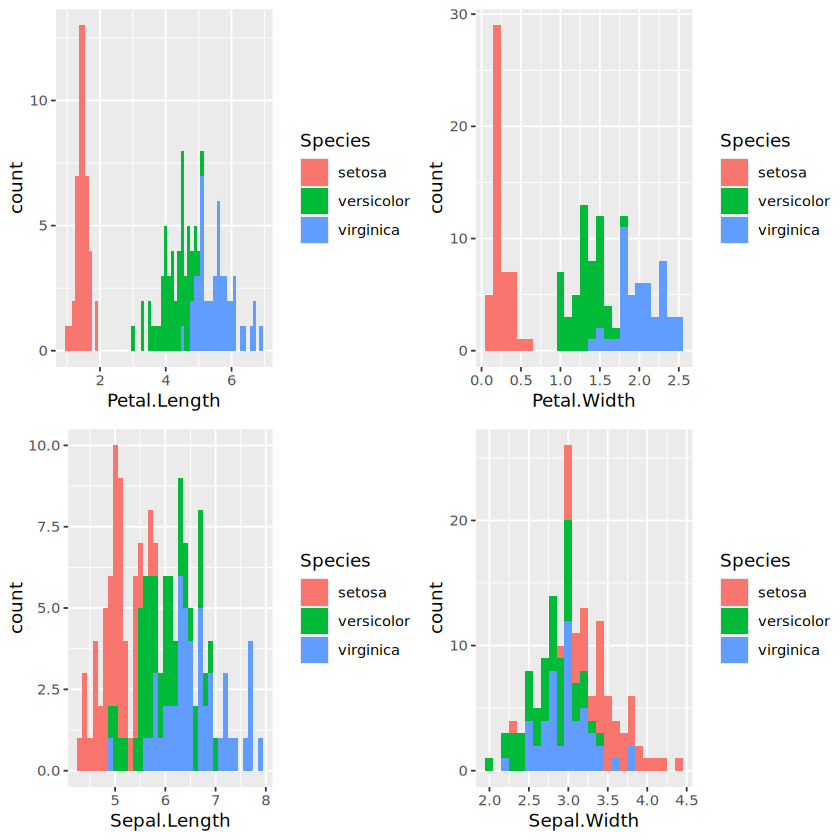

In [22]:
# 19. 多张直方图
plen <- ggplot(iris, aes(x=Petal.Length, fill=Species)) + geom_histogram(binwidth=0.1) 
pwth <- ggplot(iris, aes(x=Petal.Width, fill=Species)) + geom_histogram(binwidth=0.1)
slen <- ggplot(iris, aes(x=Sepal.Length, fill=Species)) + geom_histogram(binwidth=0.1)
swth <- ggplot(iris, aes(x=Sepal.Width, fill=Species)) + geom_histogram(binwidth=0.1)
gridExtra::grid.arrange(plen, pwth, slen, swth, nrow=2)  # gridExtra是常用的一个绘图布局包

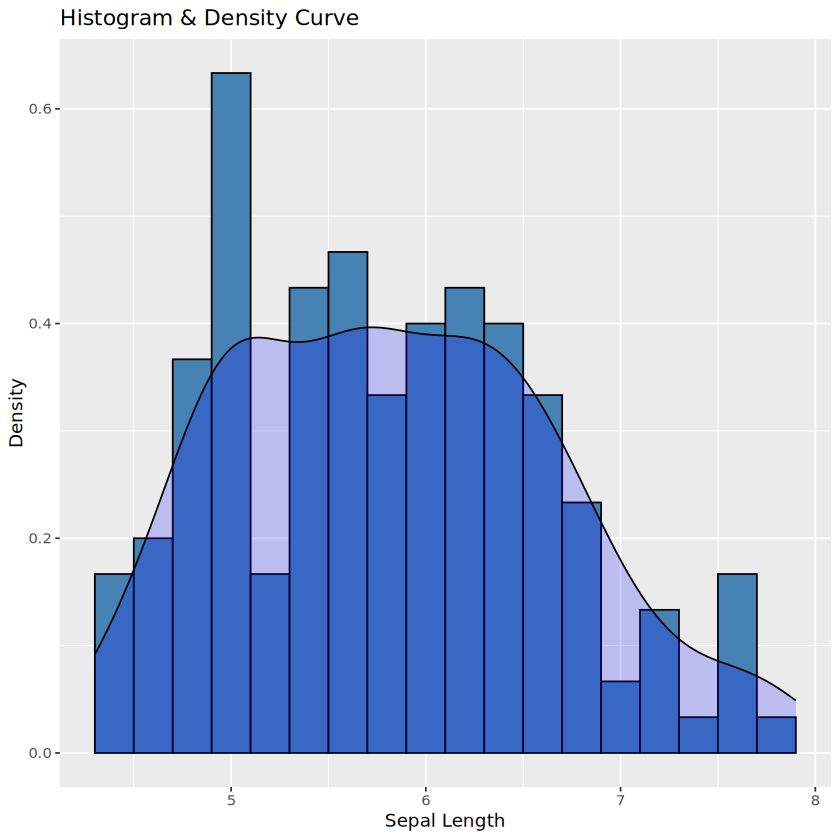

In [23]:
# 20. ggplot > 密度分布图
d1 <- ggplot(iris, aes(x=Sepal.Length))
d1 + geom_histogram(binwidth=0.2, col='black', fill='steelblue', aes(y=after_stat(density))) +  # 直方图  
    geom_density(stat='density', alpha=I(0.2), fill='blue') +  # 密度图
    xlab('Sepal Length') + 
    ylab('Density') + 
    ggtitle('Histogram & Density Curve')

# after_stat: 将直方图的纵轴（默认为stat_bin统计变换得到的频数）转换为密度，（原dot-dot表达式）
# I(): 变量保护函数

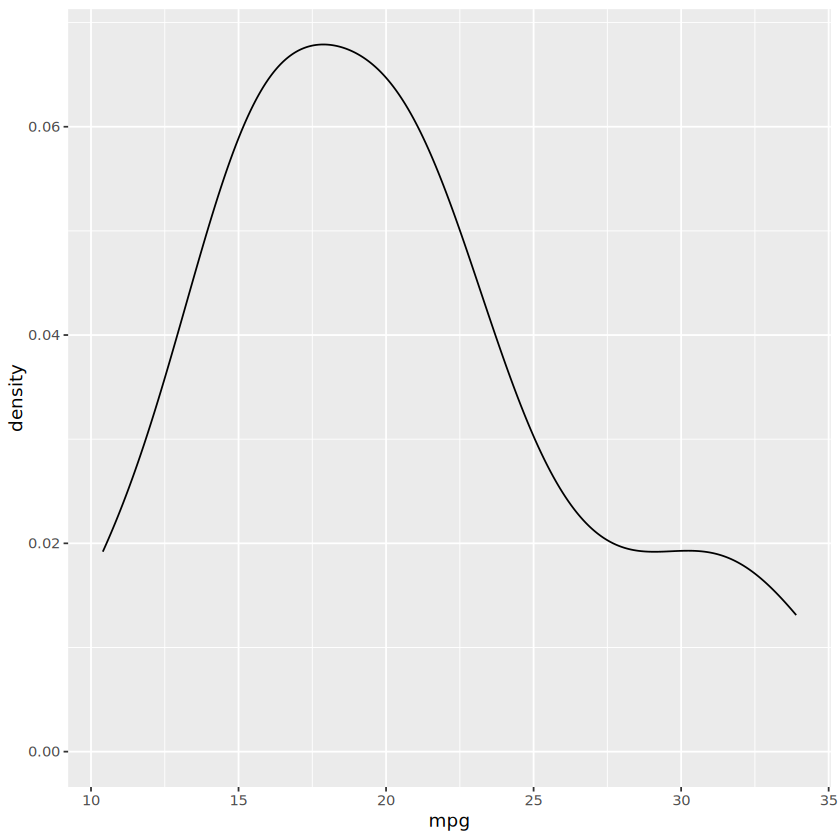

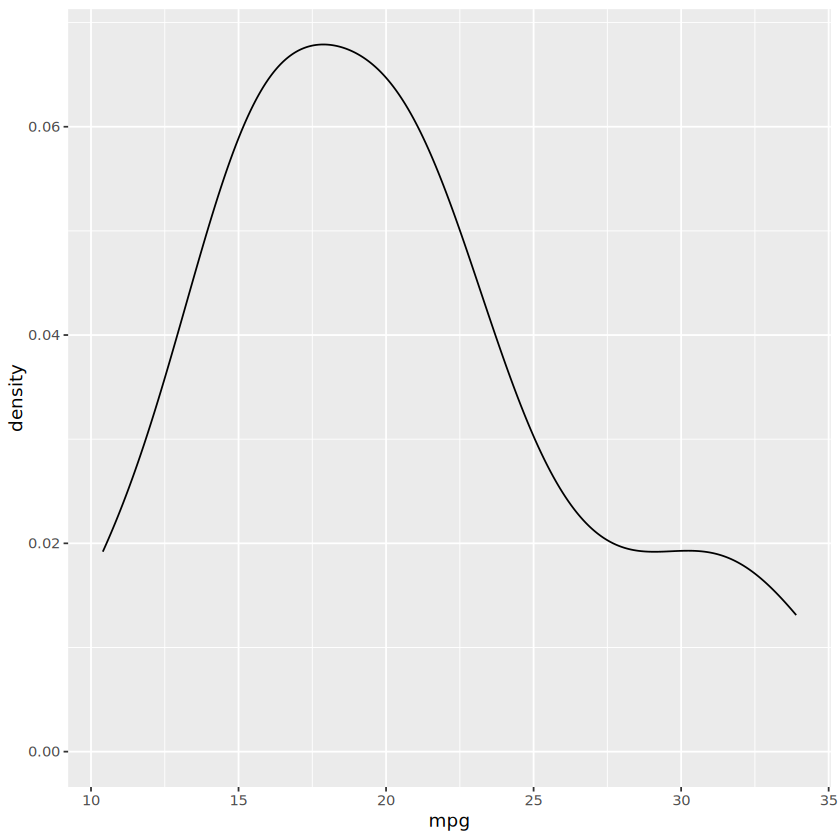

In [24]:
# 22. geom_与stat_的关系
ggplot(mtcars, aes(x=mpg)) + geom_density()  # 默认stat="density"
ggplot(mtcars, aes(x=mpg)) + stat_density(geom="line")

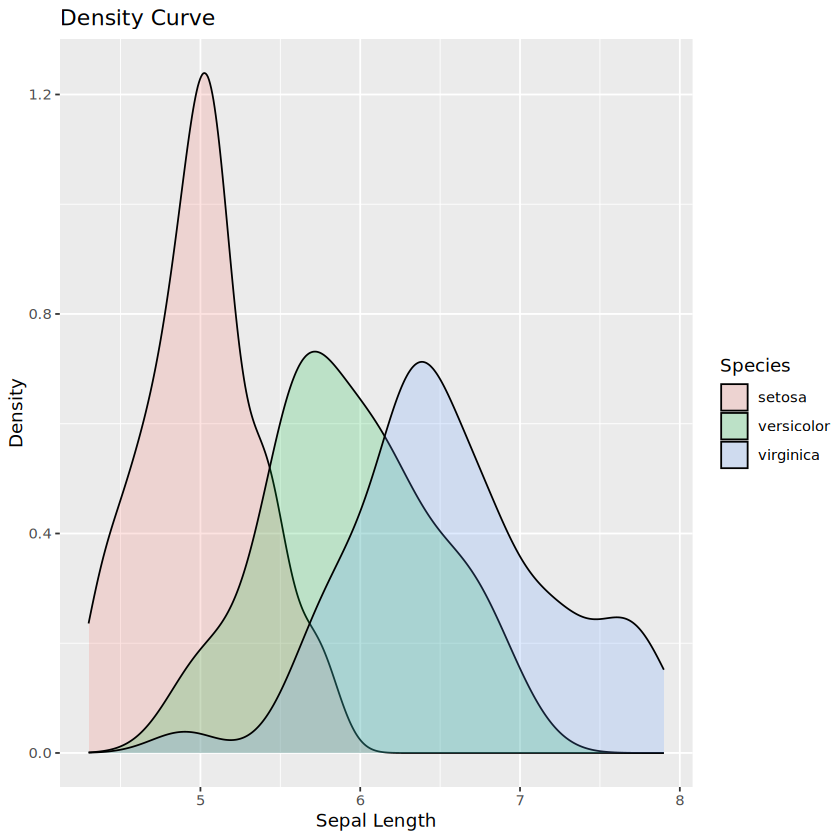

In [25]:
# 23. 按类别分组后的密度分布图
d2 <- ggplot(iris, aes(x=Sepal.Length, fill=Species))
d2 + geom_density(alpha=0.2) + 
    xlab('Sepal Length') + 
    ylab('Density') + 
    ggtitle('Density Curve')

In [26]:
# 24. 窄格式数据
library(reshape2)  # 一个用于数据重塑的常用包
df2 <- melt(iris, id.vars='Species')  # 以Species为主键重塑，其他列全部表示为variable和value
head(df2)
head(iris)

,Species,variable,value
,<fct>,<fct>,<dbl>
1,setosa,Sepal.Length,5.1
2,setosa,Sepal.Length,4.9
3,setosa,Sepal.Length,4.7
4,setosa,Sepal.Length,4.6
5,setosa,Sepal.Length,5.0
6,setosa,Sepal.Length,5.4


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


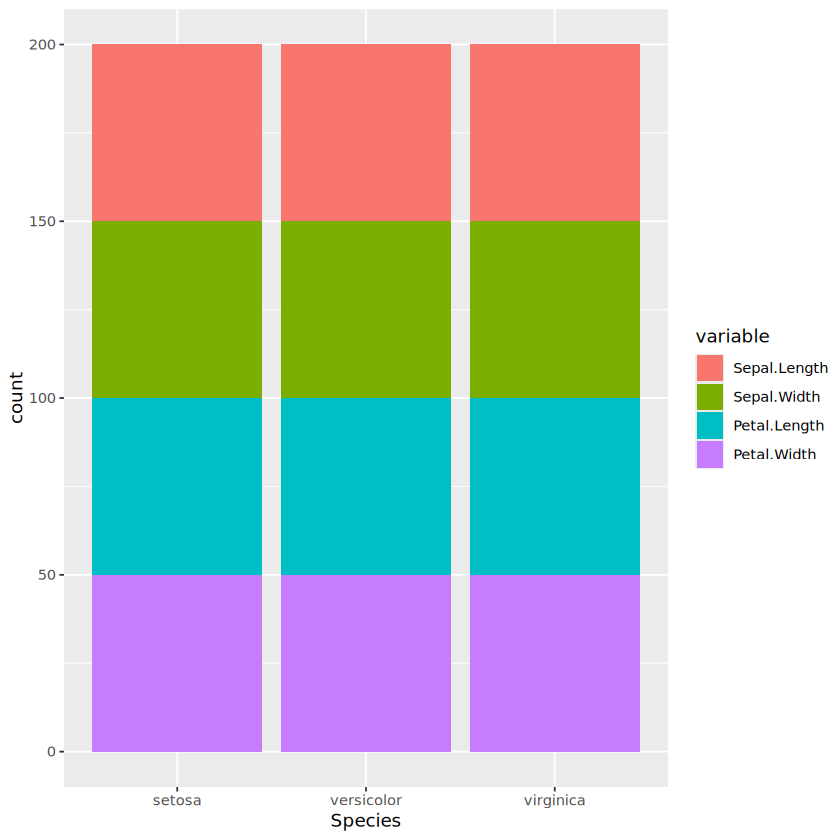

In [27]:
# 25. ggplot > 条形图
ggplot(df2, aes(x=Species, fill=variable)) + geom_bar()  # 样本数，仅指定x

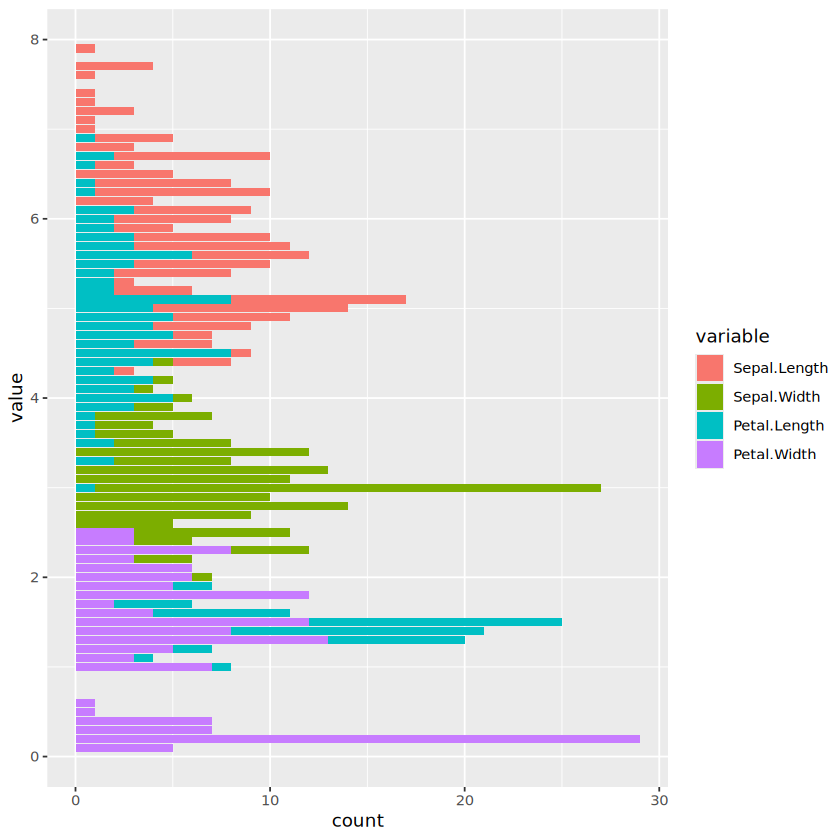

In [28]:
ggplot(df2, aes(y=value, fill=variable)) + geom_bar()  # 值的计数，仅指定y

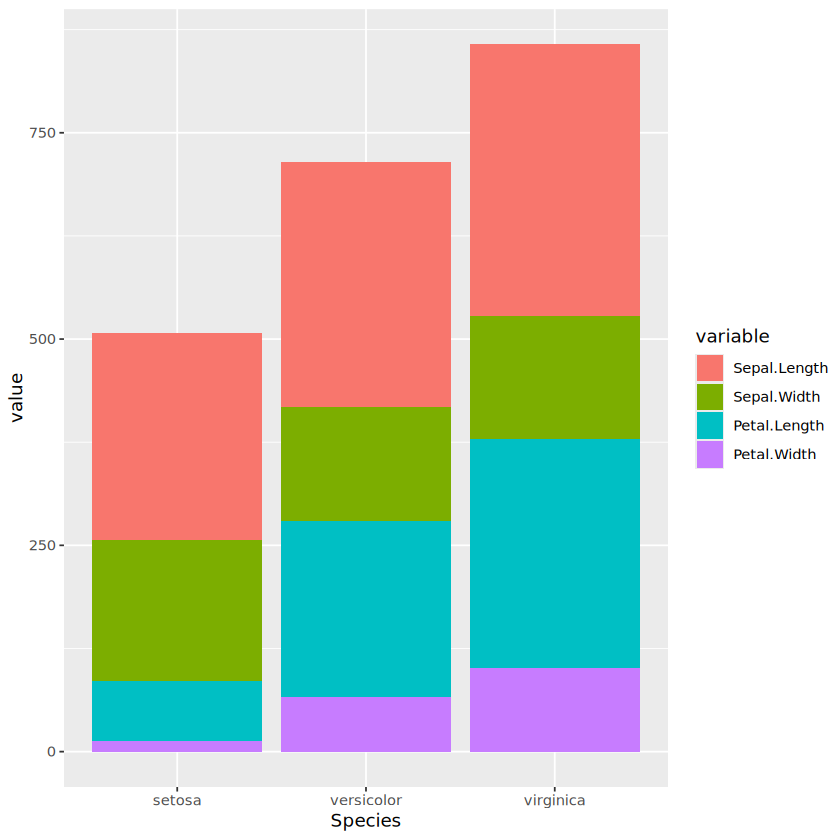

In [29]:
# 26. 分组统计
bar1 <- ggplot(data=df2, aes(x=Species, y=value, fill=variable))
bar1 + geom_bar(stat='identity')  # 统计变换保留原值，相同x则求和，并堆叠

In [30]:
setosa <- subset(iris, Species=='setosa')
sum(setosa$Sepal.Width, setosa$Petal.Length, setosa$Petal.Width)  # 上图第一列的和

[1] 256.8

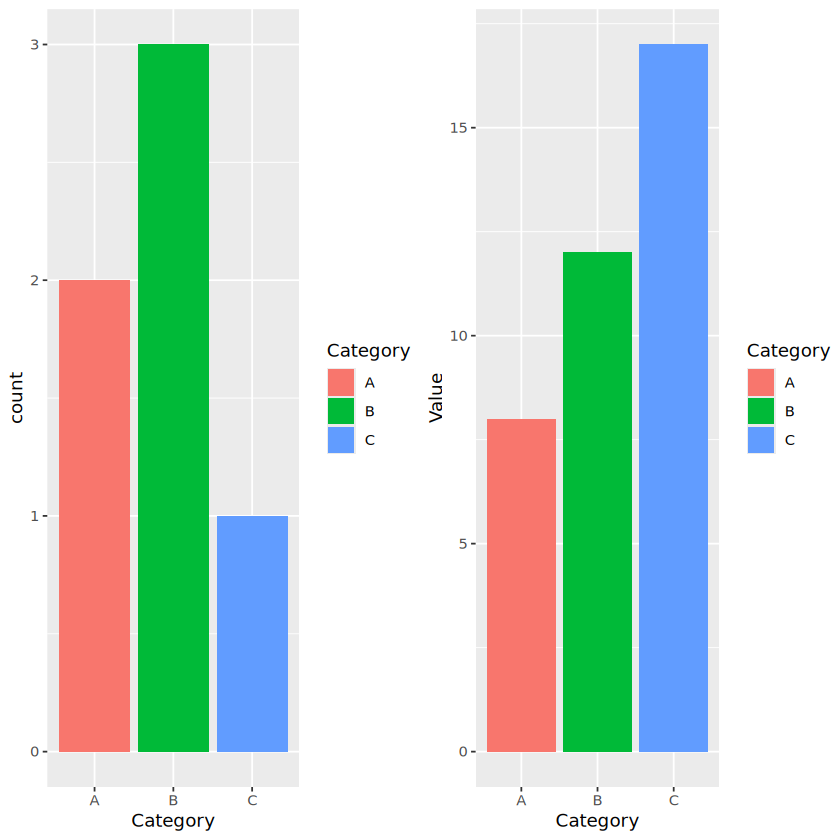

In [31]:
# 27. stat="count"与stat="identity"区别
data <- data.frame(
    Category = c("A", "A", "B", "B", "B", "C"),
    Value = c(3, 5, 2, 4, 6, 17)
)

gridExtra::grid.arrange(
    ggplot(data, aes(x=Category)) + geom_bar(aes(fill=Category)),
    ggplot(data, aes(x=Category, y=Value)) + geom_bar(aes(fill=Category), stat="identity"),  # 将value作为y值，即求和
    nrow=1)

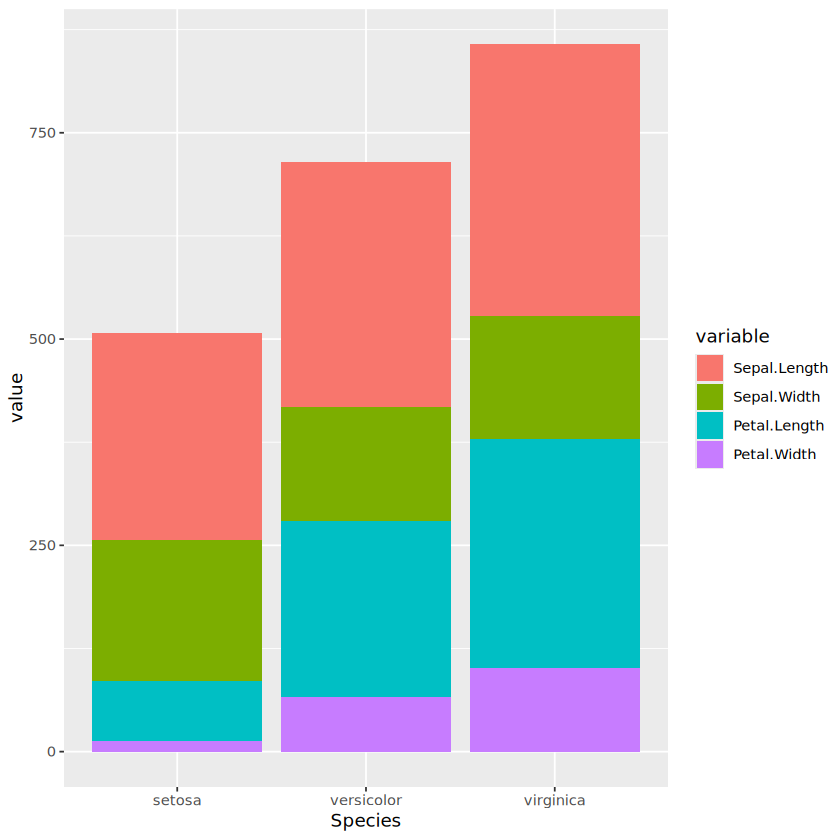

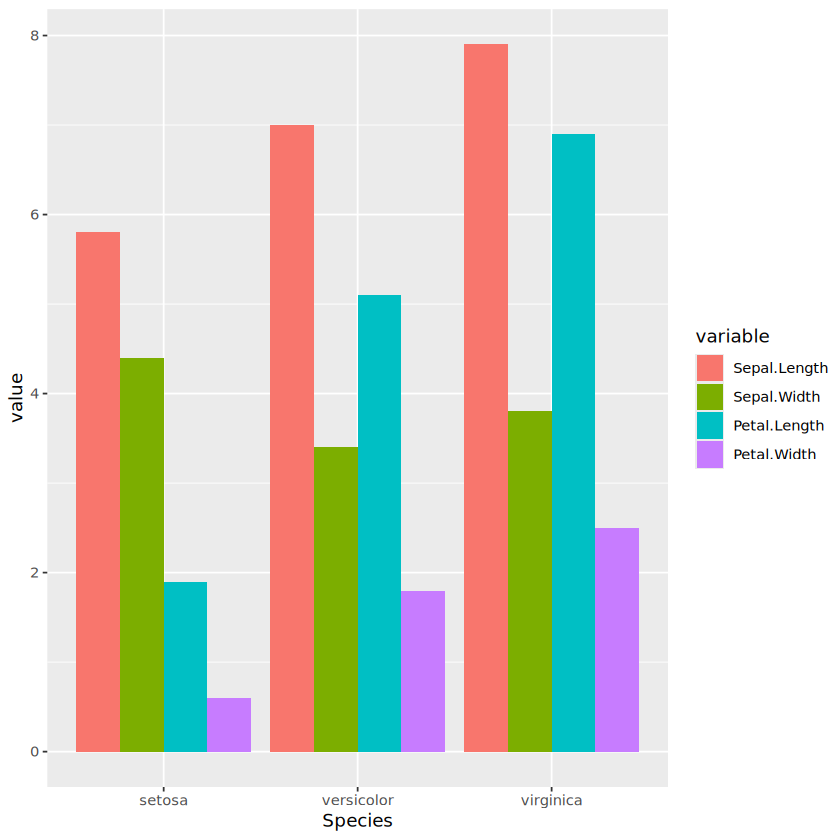

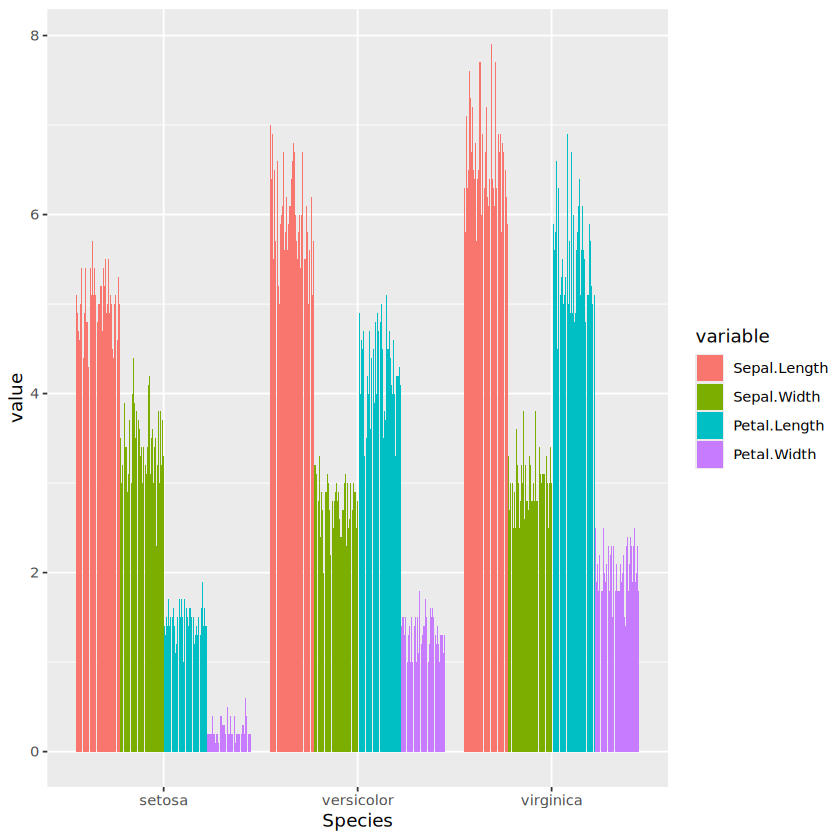

In [32]:
# 28. 不同position的区别
ggplot(df2, aes(x=Species, y=value, fill=variable)) + geom_bar(stat='identity', position='stack')
ggplot(df2, aes(x=Species, y=value, fill=variable)) + geom_bar(stat='identity', position='dodge')
ggplot(df2, aes(x=Species, y=value, fill=variable)) + geom_bar(stat="identity", position="dodge2")  # 并排无分组

# also `position=position_dodge()`, `position_stack()`, `position_dodge2()`

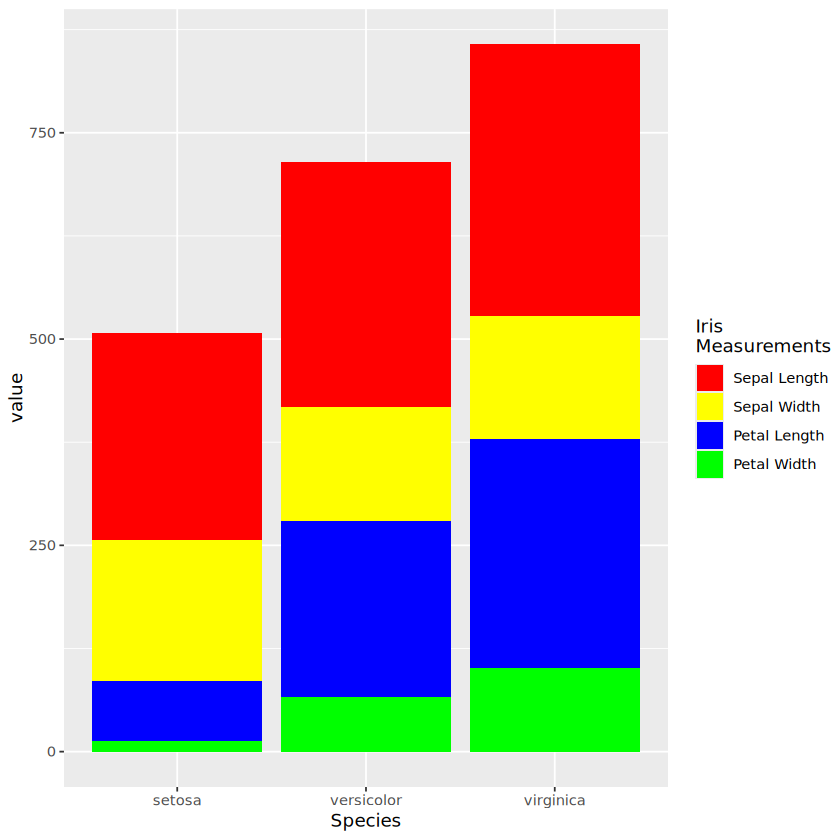

In [33]:
# 29. scale_manual设置美学映射
ggplot(df2, aes(x=Species, y=value, fill=variable)) + 
    geom_bar(stat="identity") + 
    scale_fill_manual(values=c("red", "yellow", "blue", "green"), 
                      name="Iris\nMeasurements", 
                      breaks=c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"), 
                      labels=c("Sepal Length", "Sepal Width", "Petal Length", "Petal Width"))

# scale_manual: 包括scale_colour_manual, _fill_, _size_, _shape_等

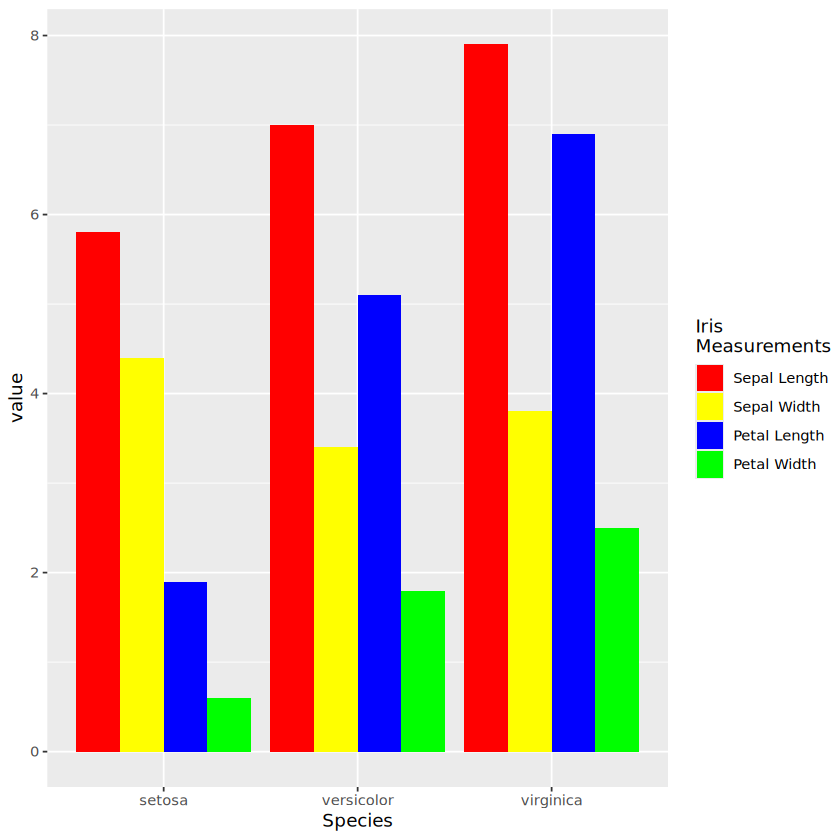

In [34]:
ggplot(df2, aes(x=Species, y=value, fill=variable)) + 
    geom_bar(stat="identity", position="dodge") + 
    scale_fill_manual(values=c("red", "yellow", "blue", "green"), 
                      name="Iris\nMeasurements", 
                      breaks=c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"), 
                      labels=c("Sepal Length", "Sepal Width", "Petal Length", "Petal Width"))

In [35]:
# 30. ggplot > 线图
head(Orange)
Orange$Tree  # 桔子树的成长数据集，包括树（有序因子）、天数、圆周长三列

,Tree,age,circumference
,<ord>,<dbl>,<dbl>
1,1,118,30
2,1,484,58
3,1,664,87
4,1,1004,115
5,1,1231,120
6,1,1372,142


[1] 1 1 1 1 1 1 1 2 2 2 2 2 2 2 3 3 3 3 3 3 3 4 4 4 4 4 4 4 5 5 5 5 5 5 5
Levels: 3 < 1 < 5 < 2 < 4

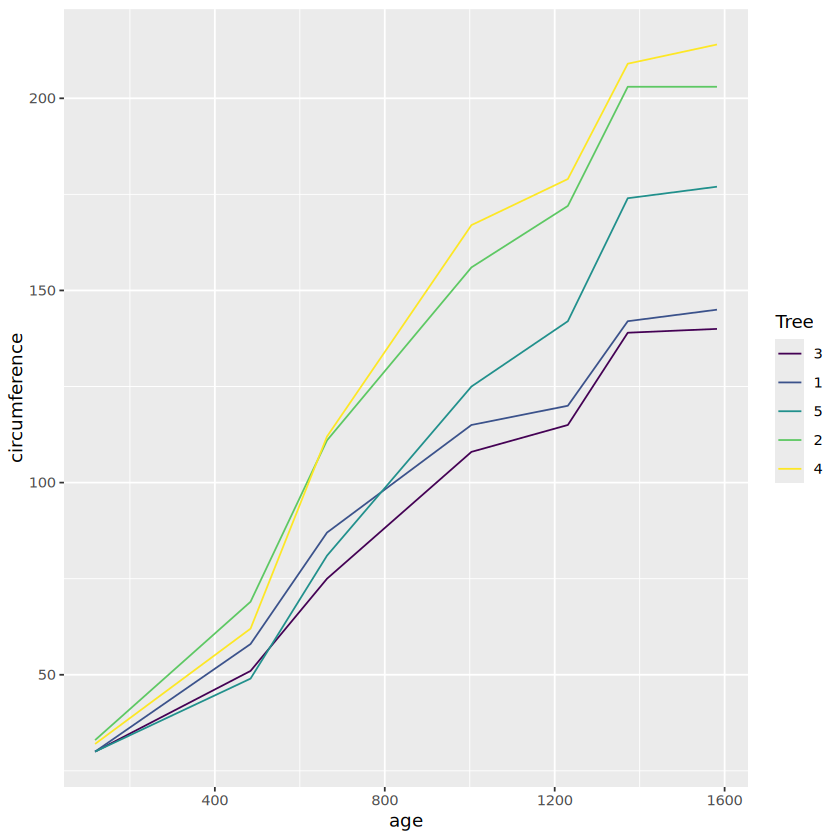

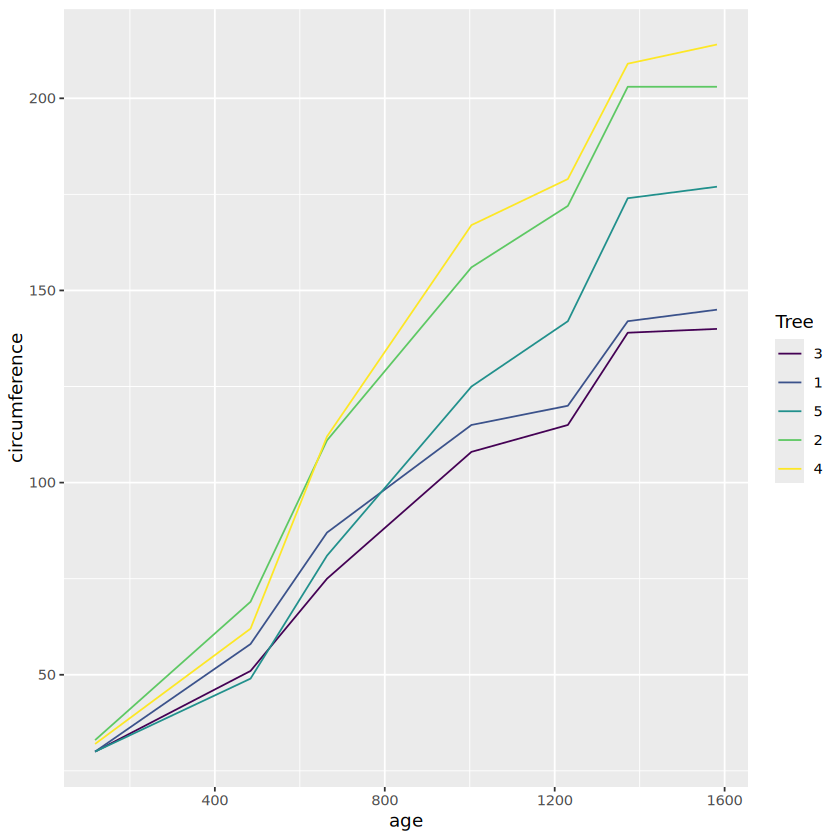

In [36]:
ggplot(Orange) + geom_line(aes(x=age, y=circumference, color=Tree))
ggplot(Orange, aes(x=age, y=circumference, color=Tree)) + geom_line()

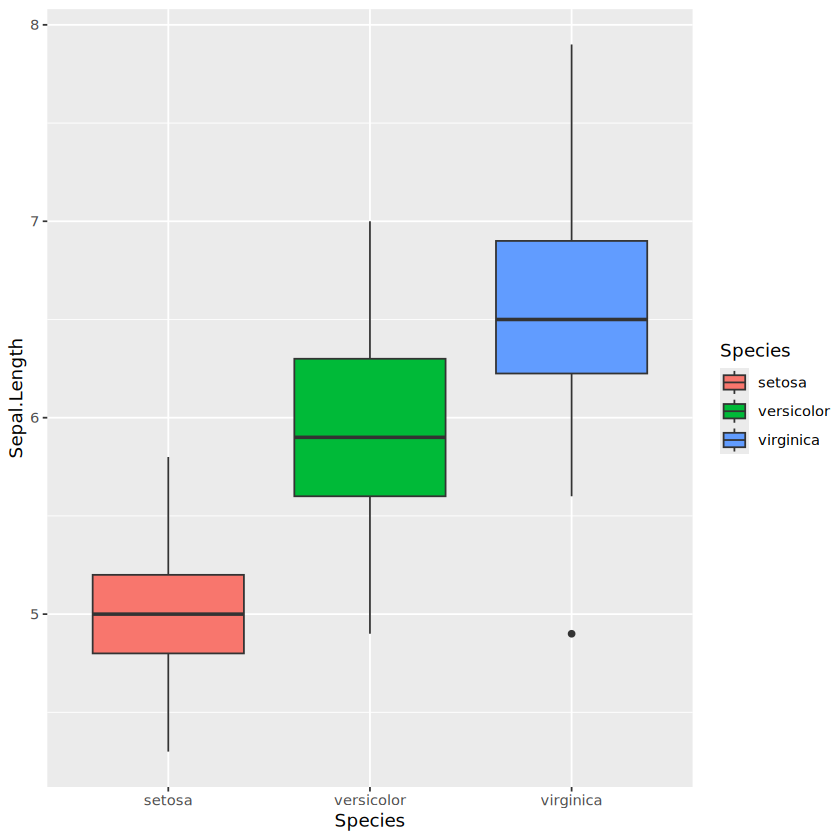

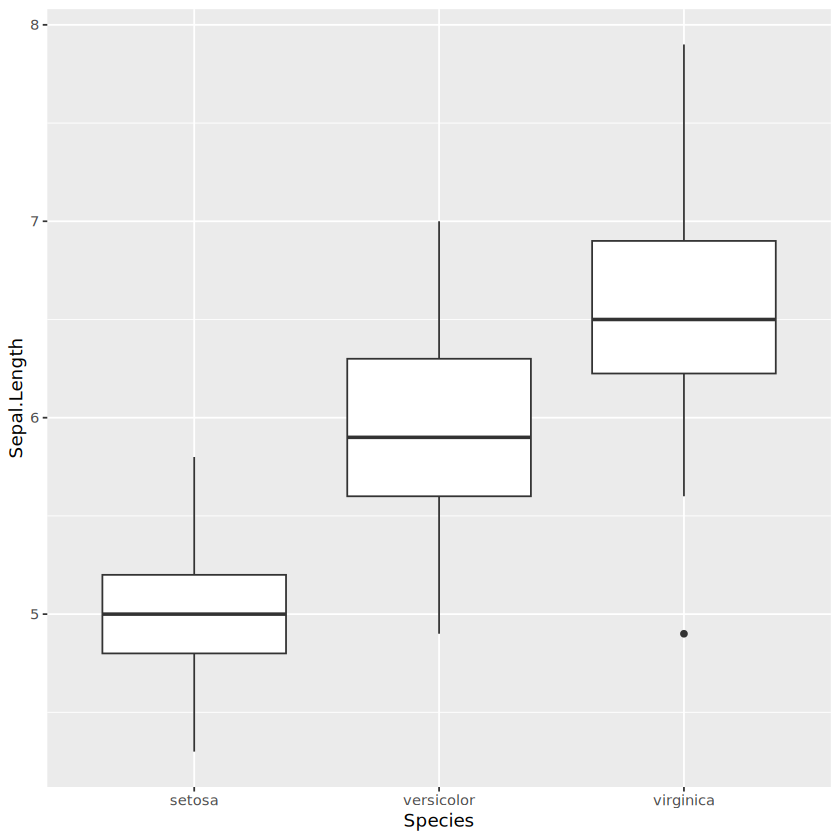

In [37]:
# 31. ggplot > 盒形图
ggplot(iris, aes(x=Species, y=Sepal.Length)) + geom_boxplot(aes(fill=Species))
ggplot(iris, aes(x=Species, y=Sepal.Length)) + geom_boxplot()

## 3. 探索性数据分析

### 3.1 数据准备与预处理

In [38]:
# 32. 泰坦尼克号乘客生存情况
df <- read.csv('train.csv', na.strings='')  # 将空字符串视为NA
head(df)
summary(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NA,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NA,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NA,S
6,6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,NA,Q


  PassengerId       Survived          Pclass          Name          
 Min.   :  1.0   Min.   :0.0000   Min.   :1.000   Length:891        
 1st Qu.:223.5   1st Qu.:0.0000   1st Qu.:2.000   Class :character  
 Median :446.0   Median :0.0000   Median :3.000   Mode  :character  
 Mean   :446.0   Mean   :0.3838   Mean   :2.309                     
 3rd Qu.:668.5   3rd Qu.:1.0000   3rd Qu.:3.000                     
 Max.   :891.0   Max.   :1.0000   Max.   :3.000                     
                                                                    
     Sex                 Age            SibSp           Parch       
 Length:891         Min.   : 0.42   Min.   :0.000   Min.   :0.0000  
 Class :character   1st Qu.:20.12   1st Qu.:0.000   1st Qu.:0.0000  
 Mode  :character   Median :28.00   Median :0.000   Median :0.0000  
                    Mean   :29.70   Mean   :0.523   Mean   :0.3816  
                    3rd Qu.:38.00   3rd Qu.:1.000   3rd Qu.:0.0000  
                    Max.   :80.00 

In [39]:
# 33. 处理缺失值
sum(is.na(df))
colSums(is.na(df))  # 每列的缺失值数

[1] 866

PassengerId    Survived      Pclass        Name         Sex         Age 
          0           0           0           0           0         177 
      SibSp       Parch      Ticket        Fare       Cabin    Embarked 
          0           0           0           0         687           2

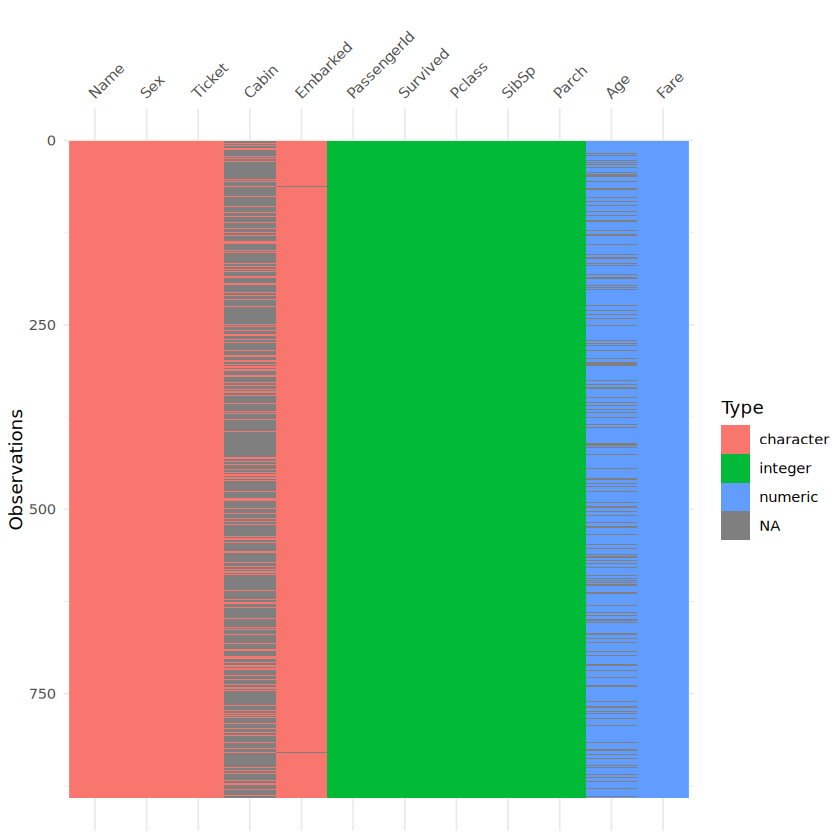

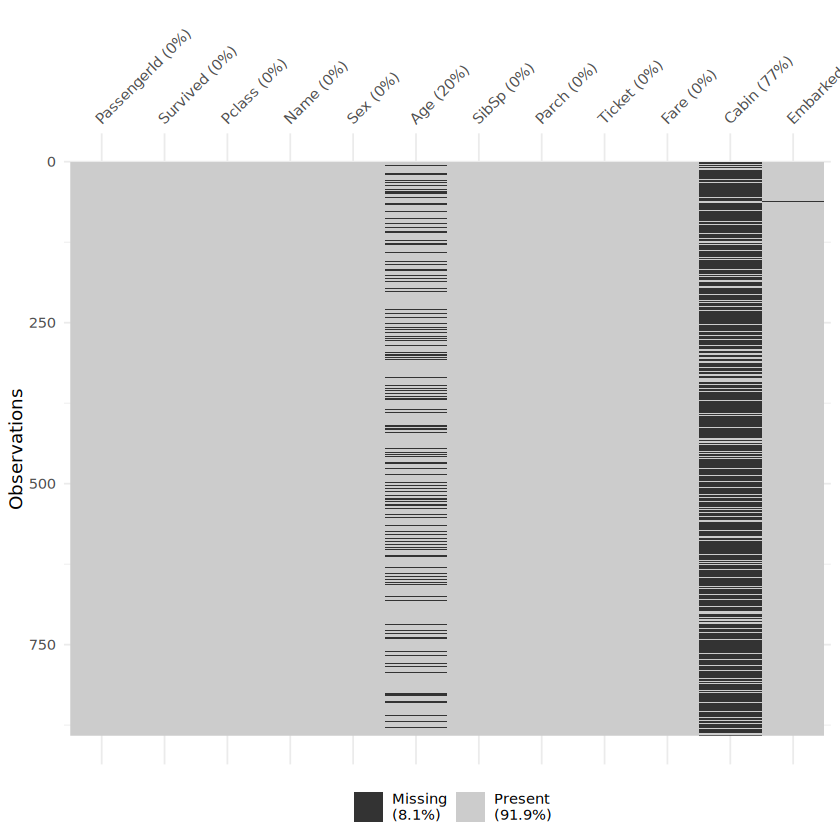

In [40]:
# 查看缺失值
library(visdat)  # 一个数据初步探索性可视化工具
vis_dat(df)  # 显示列的类别和缺失值
vis_miss(df)  # 只显示缺失值

In [41]:
# 保留有用的列
library(dplyr)
df <- select(df, Survived, Pclass, Age, Sex, SibSp, Parch)
str(df)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




'data.frame':	891 obs. of  6 variables:
 $ Survived: int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass  : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Age     : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ Sex     : chr  "male" "female" "female" "female" ...
 $ SibSp   : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch   : int  0 0 0 0 0 0 0 1 2 0 ...


In [42]:
# 删除有缺失值的记录
sum(is.na(df))
df <- na.omit(df)
str(df)

[1] 177

'data.frame':	714 obs. of  6 variables:
 $ Survived: int  0 1 1 1 0 0 0 1 1 1 ...
 $ Pclass  : int  3 1 3 1 3 1 3 3 2 3 ...
 $ Age     : num  22 38 26 35 35 54 2 27 14 4 ...
 $ Sex     : chr  "male" "female" "female" "female" ...
 $ SibSp   : int  1 1 0 1 0 0 3 0 1 1 ...
 $ Parch   : int  0 0 0 0 0 0 1 2 0 1 ...
 - attr(*, "na.action")= 'omit' Named int [1:177] 6 18 20 27 29 30 32 33 37 43 ...
  ..- attr(*, "names")= chr [1:177] "6" "18" "20" "27" ...


In [43]:
# 34. 数据清洗
df$Survived <- factor(df$Survived)
df$Pclass = factor(df$Pclass)
str(df)

'data.frame':	714 obs. of  6 variables:
 $ Survived: Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 2 2 2 ...
 $ Pclass  : Factor w/ 3 levels "1","2","3": 3 1 3 1 3 1 3 3 2 3 ...
 $ Age     : num  22 38 26 35 35 54 2 27 14 4 ...
 $ Sex     : chr  "male" "female" "female" "female" ...
 $ SibSp   : int  1 1 0 1 0 0 3 0 1 1 ...
 $ Parch   : int  0 0 0 0 0 0 1 2 0 1 ...
 - attr(*, "na.action")= 'omit' Named int [1:177] 6 18 20 27 29 30 32 33 37 43 ...
  ..- attr(*, "names")= chr [1:177] "6" "18" "20" "27" ...


### 3.2 数据可视化

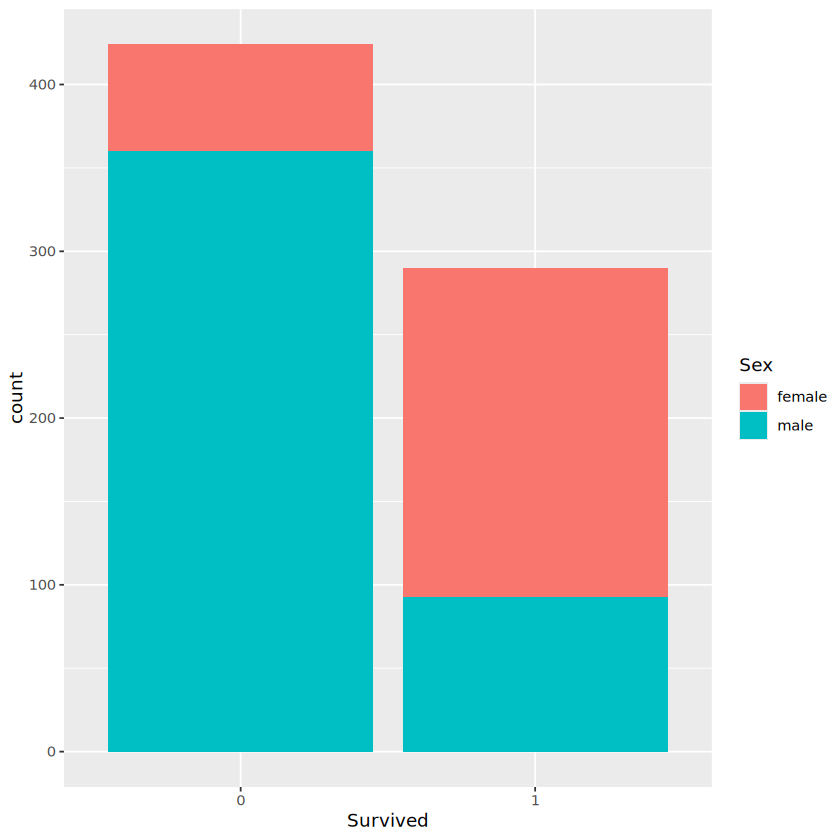

In [44]:
# 35. 查看是否存活与性别之间的关系
ggplot(df, aes(x=Survived, fill=Sex)) + geom_bar()

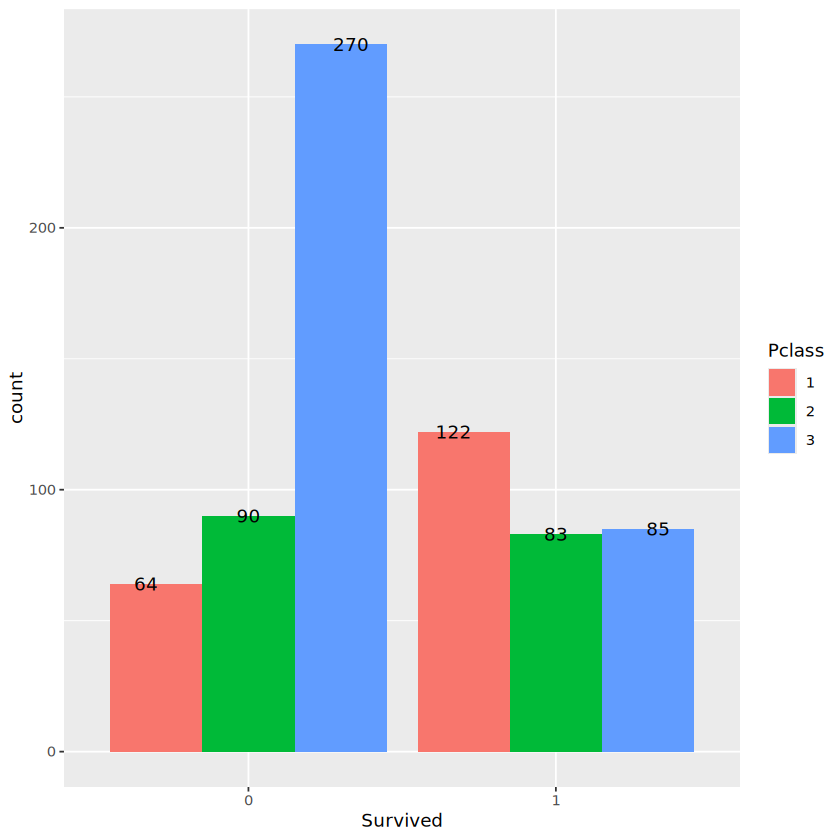

In [45]:
# 36. 查看是否存活与船舱等级的关系
ggplot(df, aes(x=Survived, fill=Pclass)) + geom_bar(position="dodge") + 
    geom_text(stat="count", aes(label=after_stat(count)), position=position_dodge(width=1))

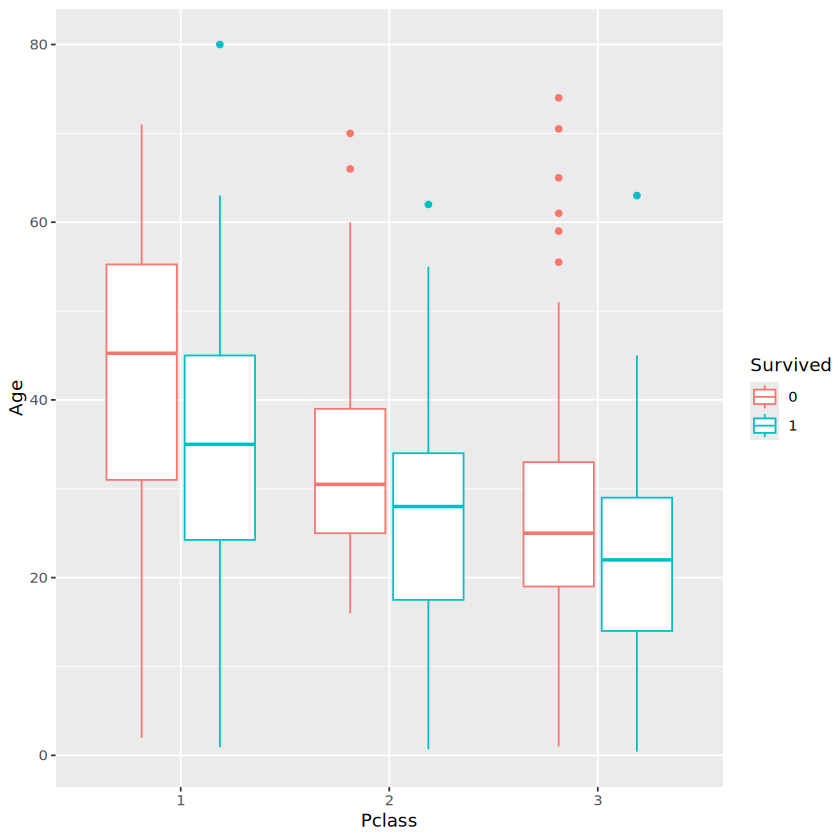

In [46]:
# 37. 查看船舱等级、年龄与是否存活之间的关系
ggplot(df, aes(Pclass, Age, color=Survived)) + geom_boxplot()

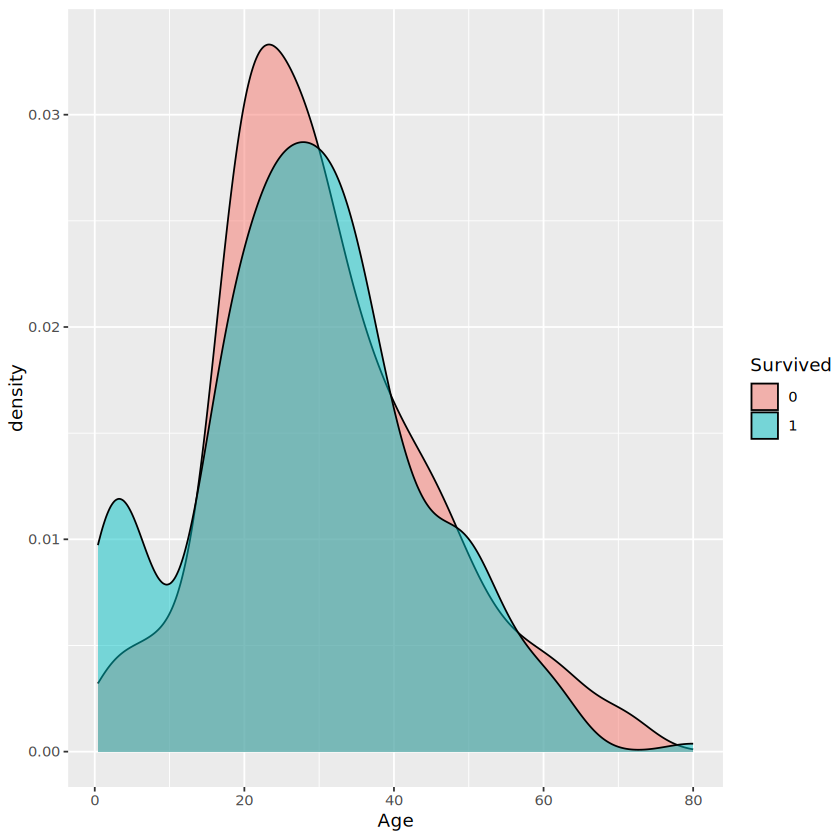

In [47]:
# 38. 查看年龄与是否存活之间的关系，使用密度图表示
ggplot(df, aes(x=Age)) + geom_density(aes(fill=Survived), alpha=0.5)

### 3.3 相关性分析

In [48]:
# 39. 将类别数据转为数值
df_corr <- df
df_corr$Survived <- as.numeric(df_corr$Survived)
df_corr$Pclass <- as.numeric(df_corr$Pclass)
df_corr$Sex <- ifelse(df_corr$Sex=='male', 1, 0)
str(df_corr)

'data.frame':	714 obs. of  6 variables:
 $ Survived: num  1 2 2 2 1 1 1 2 2 2 ...
 $ Pclass  : num  3 1 3 1 3 1 3 3 2 3 ...
 $ Age     : num  22 38 26 35 35 54 2 27 14 4 ...
 $ Sex     : num  1 0 0 0 1 1 1 0 0 0 ...
 $ SibSp   : int  1 1 0 1 0 0 3 0 1 1 ...
 $ Parch   : int  0 0 0 0 0 0 1 2 0 1 ...
 - attr(*, "na.action")= 'omit' Named int [1:177] 6 18 20 27 29 30 32 33 37 43 ...
  ..- attr(*, "names")= chr [1:177] "6" "18" "20" "27" ...


In [49]:
# 40. 计算变量间的相关系数
cor(df_corr)  # 默认皮尔逊系数

,Survived,Pclass,Age,Sex,SibSp,Parch
Survived,1.00000000,-0.35965268,-0.07722109,-0.53882559,-0.01735836,0.09331701
Pclass,-0.35965268,1.00000000,-0.36922602,0.15546030,0.06724737,0.02568307
Age,-0.07722109,-0.36922602,1.00000000,0.09325358,-0.30824676,-0.18911926
Sex,-0.53882559,0.15546030,0.09325358,1.00000000,-0.10394968,-0.24697204
SibSp,-0.01735836,0.06724737,-0.30824676,-0.10394968,1.00000000,0.38381986
Parch,0.09331701,0.02568307,-0.18911926,-0.24697204,0.38381986,1.00000000


corrplot 0.95 loaded



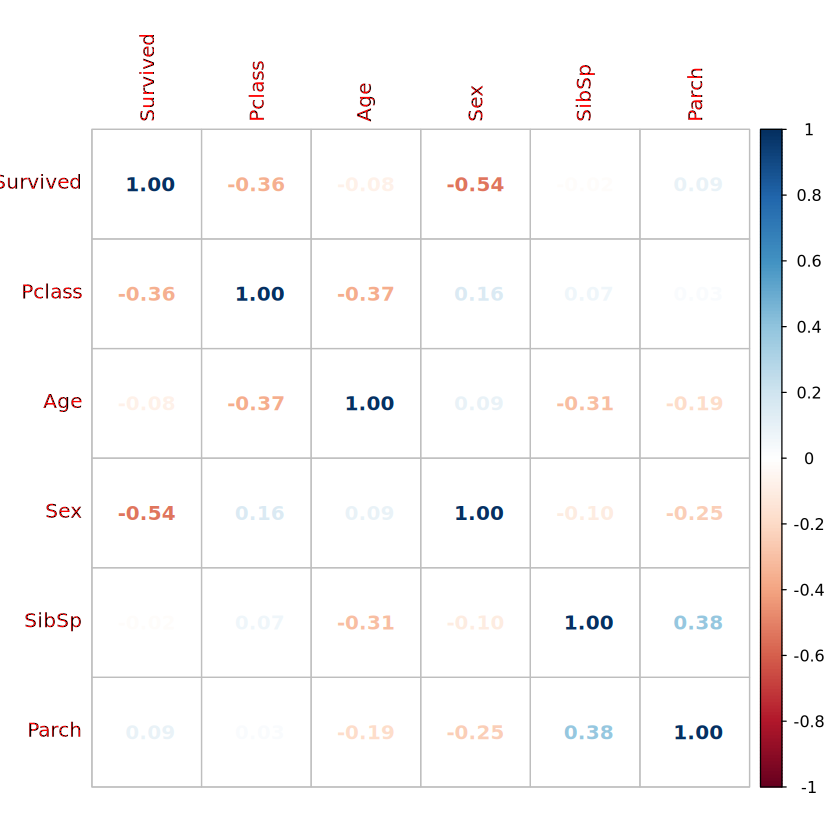

In [50]:
# 41. 绘制相关图
library(corrplot)
corrplot(cor(df_corr), method="number")

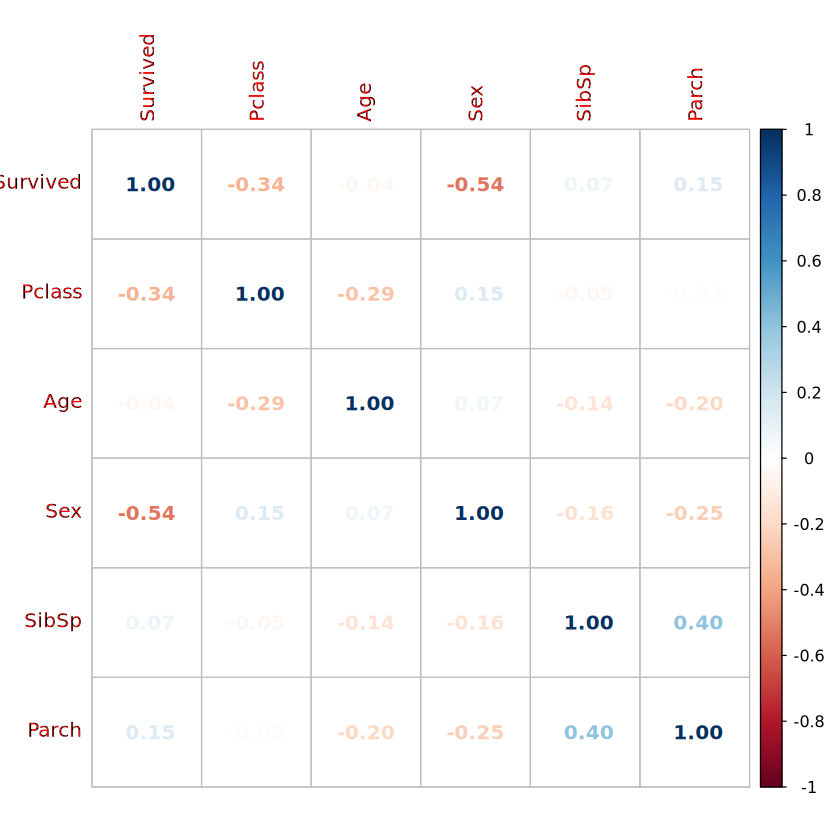

In [51]:
# 42. 使用肯德尔相关系数
M <- cor(df_corr, method="kendall")
corrplot(M, method="number")

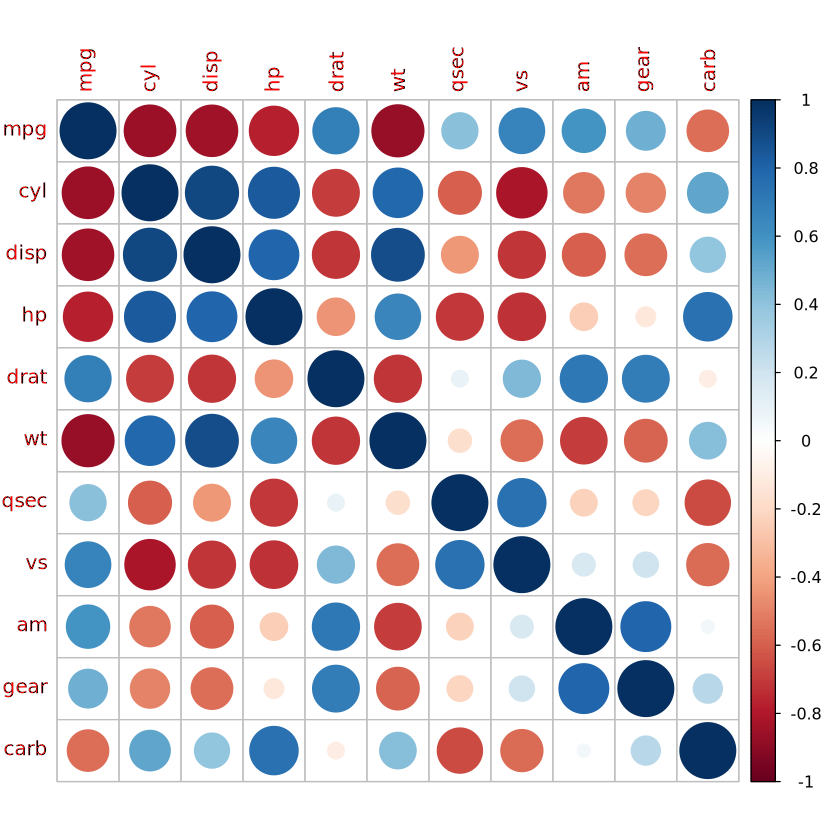

In [52]:
# 43. 查看mtcars数据集的相关系数
corrplot(cor(mtcars))